# Notebook 07: Manuscript Figures and Tables (Corrected η_s = 1.263)

**Purpose:** Generate all figures and LaTeX tables for the M2 manuscript
*Along-Track Winter Snow Thickness over Antarctic Sea Ice from CRYO2ICE*,
using the corrected Kacimi/Kwok snow thickness formula.

**Data source:** Full 38-month batch-processed dataset (Aug 2022–Sep 2025),
126,283 matchups with corrected η_s = (1 + 0.51ρ_s)^1.5 = 1.263.

**Style:** Nature publication format, Okabe–Ito colorblind-safe palette.

### Outputs

| Output | Content | Manuscript section |
|--------|---------|-------------------|
| Table 1 | Summary statistics by sector | §4.1 |
| Table 2 | Density sensitivity | §4.4 |
| Table 3 | AMSR2 comparison statistics | §4.5 |
| Figure 1 | Collocation characteristics (4 panels) | §4.1 |
| Figure 2 | Regional distributions (3 panels) | §4.2, §4.3 |
| Figure 3 | Temporal evolution (2 panels) | §4.3 |
| Figure 4 | Circumpolar polar map | §4.2 |
| Figure 5 | Uncertainty decomposition (2 panels) | §4.4 |
| Figure 6 | AMSR2 benchmarking (3 panels) | §4.5 |

### Known issue
NB04 cell 6 prints `eta_s = 1.2217` using the old formula in the diagnostic
print statement, but `compute_snow_thickness()` correctly computes
h_s = Δf / 1.263. Fix the print statement in NB04 cell 6 — replace
`eta_s = 1.0 / np.sqrt(1.0 - 330.0/1000.0)` with
`eta_s = (1.0 + 0.51 * 0.33)**1.5`.

## 0. Setup: Nature Style, Colorblind Palette, Data Loading

In [1]:
import sys, os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from datetime import datetime
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')

# ─── NATURE PUBLICATION STYLE ───────────────────────────────────
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.4,
    'ytick.major.width': 0.4,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'lines.linewidth': 0.8,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42,     # editable text in PDFs
    'figure.dpi': 150,
})

# ─── COLORBLIND-SAFE PALETTE (Okabe–Ito) ────────────────────────
C_WEDDELL  = '#0072B2'   # blue
C_ROSS     = '#D55E00'   # vermillion / orange
C_OTHER    = '#999999'   # grey
C_ACCENT   = '#CC79A7'   # reddish purple
C_TEAL     = '#009E73'   # bluish green
C_SKY      = '#56B4E9'   # sky blue
C_YELLOW   = '#F0E442'   # yellow (only for sparse accents)

# ─── HELPER: Nature-style axis ──────────────────────────────────
def nature_ax(ax, xlabel=None, ylabel=None, title=None):
    """Remove top/right spines; set labels; bold panel letter."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title:  ax.set_title(title, fontweight='bold', loc='left', pad=4)

# ─── OUTPUT DIRECTORY ────────────────────────────────────────────
FIG_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/output/figures'
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Figures will be saved to: {FIG_DIR}')
print('Style: Nature | Palette: Okabe-Ito (colorblind-safe)')


Figures will be saved to: /g/data/gv90/xl1657/phd/M2_workspace/output/figures
Style: Nature | Palette: Okabe-Ito (colorblind-safe)


## 1. Load Full Dataset and Match AMSR2

**Data source:** 38 collocated CSV files from `batch_process.py` in
`/g/data/gv90/xl1657/phd/M2_workspace/output/collocated/`.

Each file (`collocated_YYYYMM.csv`) contains 14 columns including
pre-computed `snow_thickness` and `snow_thickness_unc` with the
corrected η_s = 1.263 formula.

AMSR2 matching is performed here (not pre-computed) and cached
to `snow_thickness_with_amsr2_all.csv` for fast subsequent loads.


In [2]:
# ─── FILE PATHS ──────────────────────────────────────────────────
COL_DIR   = '/g/data/gv90/xl1657/phd/M2_workspace/output/collocated'
HS_DIR    = '/g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness'
AMSR2_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/data/auxiliary/AMSR2'
CACHE     = f'{HS_DIR}/snow_thickness_with_amsr2_all.csv'

os.makedirs(HS_DIR, exist_ok=True)

# ─── CHECK FOR CACHED AMSR2-MATCHED FILE ─────────────────────────
if os.path.exists(CACHE):
    df = pd.read_csv(CACHE)
    has_amsr2 = 'AMSR2_snow_depth' in df.columns
    print(f'Loaded cached file: {CACHE}')
    print(f'  Rows: {len(df):,}  |  AMSR2: {has_amsr2}')

else:
    # ─── STEP 1: Load all 38 collocated CSVs ─────────────────────
    csv_files = sorted(glob.glob(f'{COL_DIR}/collocated_2*.csv'))
    print(f'Found {len(csv_files)} collocated CSV files in {COL_DIR}')
    if len(csv_files) == 0:
        raise FileNotFoundError(f'No collocated_2*.csv files in {COL_DIR}')

    df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
    print(f'Combined: {len(df):,} matchups from {len(csv_files)} months')
    print(f'Columns: {list(df.columns)}')

    # ─── STEP 2: Match AMSR2 for each month ──────────────────────
    from utils import read_amsr2_sh, match_amsr2_nn

    amsr2_files = sorted(glob.glob(f'{AMSR2_DIR}/*.he5'))
    print(f'AMSR2 files available: {len(amsr2_files)}')

    # Build date lookup: AMSR_U2_L3_SeaIce12km_B04_YYYYMMDD.he5
    amsr2_by_date = {}
    for f in amsr2_files:
        parts = os.path.basename(f).replace('.he5', '').split('_')
        for p in parts:
            if len(p) == 8 and p.isdigit():
                amsr2_by_date[p] = f
                break

    print(f'AMSR2 dates indexed: {len(amsr2_by_date)} '
          f'({sorted(amsr2_by_date.keys())[0]} to {sorted(amsr2_by_date.keys())[-1]})')

    # Match month by month using mid-month AMSR2 file
    chunks = []
    for ym in sorted(df.year_month.unique()):
        mid = datetime.strptime(f'{ym}15', '%Y%m%d')
        avail = sorted(amsr2_by_date.keys())
        closest = min(avail, key=lambda d: abs((datetime.strptime(d, '%Y%m%d') - mid).days))
        gap = abs((datetime.strptime(closest, '%Y%m%d') - mid).days)
        if gap > 31:
            print(f'  {ym}: SKIP (no AMSR2 within 31 days)')
            df_ym = df[df.year_month == ym].copy()
            df_ym['AMSR2_snow_depth'] = np.nan
            df_ym['AMSR2_sic'] = np.nan
            chunks.append(df_ym)
            continue

        # Read AMSR2 grid for this date
        df_amsr2 = read_amsr2_sh(amsr2_by_date[closest])
        df_amsr2 = df_amsr2[(df_amsr2.sea_ice_concentration > 0) &
                            (df_amsr2.sea_ice_concentration <= 100) &
                            (df_amsr2.snow_depth >= 0) &
                            (df_amsr2.snow_depth <= 1.5)]

        df_ym = df[df.year_month == ym].copy()
        if len(df_ym) == 0:
            continue

        df_matched = match_amsr2_nn(df_ym, df_amsr2)
        chunks.append(df_matched)
        print(f'  {ym}: {len(df_matched):>6,} pts matched with AMSR2 date {closest}')

    df = pd.concat(chunks, ignore_index=True)
    has_amsr2 = 'AMSR2_snow_depth' in df.columns
    print(f'\nTotal after AMSR2 matching: {len(df):,}')

    # ─── STEP 3: Save cache for future runs ──────────────────────
    df.to_csv(CACHE, index=False)
    print(f'Saved to: {CACHE}')

# ─── DERIVED COLUMNS ─────────────────────────────────────────────
# year_month is integer (e.g. 202208), so use arithmetic not strings
df['year']      = df['year_month'] // 100
df['month']     = df['year_month'] % 100
df['delta_f']   = df['is2_fb_wm'] - df['cs2_rfb']

# ─── BASELINE PENETRATION FACTOR (Alex decision, 29 March 2026) ──
# The cached CSV stores snow_thickness computed at δ = 1.
# Recompute at δ = 0.70 following literature consensus of 60–90%
# Ku-band penetration (Landy et al. 2026; Nab et al. 2024;
# Fredensborg Hansen et al. 2025a).
delta_baseline = 0.70
rho_s = 330.0
eta_s = (1.0 + 0.51 * (rho_s / 1000.0)) ** 1.5  # = 1.263

# Recompute snow thickness: hs = delta_f / (δ × η_s)
df['snow_thickness'] = df['delta_f'] / (delta_baseline * eta_s)

# Recompute uncertainty: scale by 1/(δ × η_s) instead of 1/η_s
if 'snow_thickness_unc' in df.columns:
    # Original unc was computed at δ=1, so scale by 1/δ
    df['snow_thickness_unc'] = df['snow_thickness_unc'] / delta_baseline

print(f'\n  *** BASELINE: delta = {delta_baseline}, eta_s = {eta_s:.4f} ***')
print(f'  *** hs = delta_f / ({delta_baseline} x {eta_s:.4f}) = delta_f / {delta_baseline * eta_s:.4f} ***')

def assign_sector(lon):
    if -62 <= lon <= 15:
        return 'Weddell'
    elif (160 <= lon <= 180) or (-180 <= lon <= -140):
        return 'Ross'
    else:
        return 'Other'

df['sector']    = df['lon'].apply(assign_sector)
df['is_winter'] = df['month'].isin([5, 6, 7, 8, 9, 10])
df['hs_valid']  = df['snow_thickness'] > 0

# ─── WEDDELL SUB-SECTOR SPLIT AT 45°W (Alex approved, 29 March 2026) ─
# West of 45°W: MYI-dominated (Weddell Gyre western boundary)
# East of 45°W: FYI-dominated (seasonal ice)
# Following Arndt et al. (2024, TC)
def assign_weddell_subsector(row):
    if row['sector'] != 'Weddell':
        return row['sector']
    if row['lon'] < -45:
        return 'Weddell_West'
    else:
        return 'Weddell_East'

df['subsector'] = df.apply(assign_weddell_subsector, axis=1)

# ─── SUBSETS ─────────────────────────────────────────────────────
dw = df[df.is_winter & df.hs_valid].copy()
dw_all_winter = df[df.is_winter].copy()

# ─── SUMMARY ─────────────────────────────────────────────────────
print(f'\n{"="*55}')
print(f'  DATASET SUMMARY')
print(f'{"="*55}')
print(f'  Total matchups:    {len(df):>8,}')
print(f'  Months:            {df.year_month.nunique():>8}  '
      f'({df.year_month.min()} to {df.year_month.max()})')
print(f'  Winter (May-Oct):  {df.is_winter.sum():>8,}')
print(f'  Winter valid:      {len(dw):>8,}')
print(f'    Weddell:         {(dw.sector=="Weddell").sum():>8,}')
print(f'    Ross:            {(dw.sector=="Ross").sum():>8,}')
print(f'    Other:           {(dw.sector=="Other").sum():>8,}')
neg_winter = (dw_all_winter.snow_thickness <= 0).sum()
print(f'  Negative (winter): {neg_winter:>8,}  '
      f'({100*neg_winter/len(dw_all_winter):.1f}%)')
print(f'  AMSR2 available:   {has_amsr2}')

# ─── FORMULA VERIFICATION ────────────────────────────────────────
ratio = dw.snow_thickness.median() / dw.delta_f.median()
expected = 1.0 / (delta_baseline * eta_s)
print(f'\n  Formula check:')
print(f'    median(hs) / median(delta_f) = {ratio:.4f}')
print(f'    Expected 1/(delta*eta_s)     = {expected:.4f}')
print(f'    PASS: {abs(ratio - expected) < 0.01}')


Loaded cached file: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/snow_thickness_with_amsr2_all.csv
  Rows: 126,283  |  AMSR2: True

  *** BASELINE: delta = 0.7, eta_s = 1.2628 ***
  *** hs = delta_f / (0.7 x 1.2628) = delta_f / 0.8840 ***

  DATASET SUMMARY
  Total matchups:     126,283
  Months:                  38  (202208 to 202509)
  Winter (May-Oct):   106,400
  Winter valid:        93,728
    Weddell:           42,447
    Ross:              30,460
    Other:             20,821
  Negative (winter):   12,672  (11.9%)
  AMSR2 available:   True

  Formula check:
    median(hs) / median(delta_f) = 1.1313
    Expected 1/(delta*eta_s)     = 1.1313
    PASS: True


## Table 1: Summary Statistics by Sector (LaTeX) → §4.1

In [3]:
# ─── TABLE 1: Enhanced — overall + monthly, median + mean ────────
stats = {}
for sector in ['Weddell', 'Ross']:
    sub_valid = dw[dw.sector == sector]
    sub_all   = dw_all_winter[dw_all_winter.sector == sector]
    neg_n     = (sub_all.snow_thickness <= 0).sum()
    stats[sector] = {
        'n_winter':   len(sub_all),
        'n_valid':    len(sub_valid),
        'valid_pct':  100 * len(sub_valid) / len(sub_all) if len(sub_all) > 0 else 0,
        'neg_pct':    100 * neg_n / len(sub_all) if len(sub_all) > 0 else 0,
        'median_hs':  sub_valid.snow_thickness.median(),
        'mean_hs':    sub_valid.snow_thickness.mean(),
        'std_hs':     sub_valid.snow_thickness.std(),
        'iqr_lo':     sub_valid.snow_thickness.quantile(0.25),
        'iqr_hi':     sub_valid.snow_thickness.quantile(0.75),
        'median_unc': sub_valid.snow_thickness_unc.median() if 'snow_thickness_unc' in sub_valid.columns else np.nan,
    }

W = stats['Weddell']
R = stats['Ross']

print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{Summary of CRYO2ICE matchup yield and retrieved')
print(r'snow-thickness statistics for the austral winter')
print(r'(May--October, 2022--2025), stratified by sector.')
print(r'The upper panel reports overall winter statistics;')
print(r'the lower panel shows the monthly progression of')
print(r'median and mean snow thickness.}')
print(r'\label{tab:summary}')
print(r'\small')
print(r'\begin{tabular}{l r r}')
print(r'\hline')
print(r' & \textbf{Weddell Sea} & \textbf{Ross Sea} \\')
print(r'\hline')

# Overall statistics
rows = [
    ('Winter matchups',                f'{W["n_winter"]:,}',      f'{R["n_winter"]:,}'),
    (r'Valid $h_s > 0$ (\%)',          f'{W["valid_pct"]:.1f}',   f'{R["valid_pct"]:.1f}'),
    (r'Negative $h_s \leq 0$ (\%)',    f'{W["neg_pct"]:.1f}',     f'{R["neg_pct"]:.1f}'),
    (r'Median $h_s$ (m)',              f'{W["median_hs"]:.3f}',   f'{R["median_hs"]:.3f}'),
    (r'Mean $h_s$ (m)',                f'{W["mean_hs"]:.3f}',     f'{R["mean_hs"]:.3f}'),
    (r'Std.\ dev.\ $h_s$ (m)',        f'{W["std_hs"]:.3f}',      f'{R["std_hs"]:.3f}'),
    (r'IQR $h_s$ (m)',                 f'{W["iqr_lo"]:.3f}--{W["iqr_hi"]:.3f}',
                                       f'{R["iqr_lo"]:.3f}--{R["iqr_hi"]:.3f}'),
    (r'Median $\sigma_{h_s}$ (m)',     f'{W["median_unc"]:.3f}',  f'{R["median_unc"]:.3f}'),
]
for lab, w, r in rows:
    print(f'{lab} & {w} & {r} \\\\')

print(r'\hline')
print(r'\multicolumn{3}{l}{\textit{Monthly median (mean) $h_s$ (m)}} \\')
print(r'\hline')

# Monthly rows
mn_names = {5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct'}
for mn in [5, 6, 7, 8, 9, 10]:
    w_m = dw[(dw.sector == 'Weddell') & (dw.month == mn)]
    r_m = dw[(dw.sector == 'Ross') & (dw.month == mn)]
    w_str = f'{w_m.snow_thickness.median():.3f} ({w_m.snow_thickness.mean():.3f})' if len(w_m) > 0 else '---'
    r_str = f'{r_m.snow_thickness.median():.3f} ({r_m.snow_thickness.mean():.3f})' if len(r_m) > 0 else '---'
    print(f'{mn_names[mn]} & {w_str} & {r_str} \\\\')

print(r'\hline')
print(r'\end{tabular}')
print(r'\end{table}')

# Plain-text summary
print('\n--- Plain-text summary ---')
for sector in ['Weddell', 'Ross']:
    s = stats[sector]
    print(f'{sector}: n={s["n_valid"]:,}  median={s["median_hs"]:.3f}  '
          f'mean={s["mean_hs"]:.3f}  unc={s["median_unc"]:.3f}')


\begin{table}[htbp]
\centering
\caption{Summary of CRYO2ICE matchup yield and retrieved
snow-thickness statistics for the austral winter
(May--October, 2022--2025), stratified by sector.
The upper panel reports overall winter statistics;
the lower panel shows the monthly progression of
median and mean snow thickness.}
\label{tab:summary}
\small
\begin{tabular}{l r r}
\hline
 & \textbf{Weddell Sea} & \textbf{Ross Sea} \\
\hline
Winter matchups & 47,735 & 34,606 \\
Valid $h_s > 0$ (\%) & 88.9 & 88.0 \\
Negative $h_s \leq 0$ (\%) & 11.1 & 12.0 \\
Median $h_s$ (m) & 0.188 & 0.156 \\
Mean $h_s$ (m) & 0.255 & 0.217 \\
Std.\ dev.\ $h_s$ (m) & 0.233 & 0.210 \\
IQR $h_s$ (m) & 0.097--0.339 & 0.081--0.277 \\
Median $\sigma_{h_s}$ (m) & 0.038 & 0.038 \\
\hline
\multicolumn{3}{l}{\textit{Monthly median (mean) $h_s$ (m)}} \\
\hline
May & 0.169 (0.220) & 0.120 (0.175) \\
Jun & 0.164 (0.228) & 0.138 (0.185) \\
Jul & 0.174 (0.248) & 0.168 (0.219) \\
Aug & 0.185 (0.249) & 0.156 (0.221) \\
Sep & 0.236 (

In [4]:
# ── Monthly median AND mean by sector (for §4.3) ────────────────
print('='*75)
print(f'{"Month":>7} {"Sector":>8} {"N":>6} {"Median":>8} {"Mean":>8} {"Q25":>8} {"Q75":>8}')
print('='*75)

for mn in [5, 6, 7, 8, 9, 10]:
    for sec in ['Weddell', 'Ross']:
        mask = (dw.month == mn) & (dw.sector == sec)
        sub = dw[mask]
        if len(sub) > 0:
            print(f'{mn:>7} {sec:>8} {len(sub):>6} '
                  f'{sub.snow_thickness.median():>8.3f} '
                  f'{sub.snow_thickness.mean():>8.3f} '
                  f'{sub.snow_thickness.quantile(0.25):>8.3f} '
                  f'{sub.snow_thickness.quantile(0.75):>8.3f}')

print('='*75)
print()

# ─── Δf statistics for WEDDELL + ROSS ONLY (Alex #12/#13) ────────
# Replaces the old circumpolar 106,400 computation
wr_all = df[df.is_winter & df.sector.isin(['Weddell', 'Ross'])].copy()
fb_wr = wr_all['is2_fb_wm'] - wr_all['cs2_rfb']
print(f'Winter Weddell+Ross N: {len(wr_all):,}')
print(f'  delta_f: mean={fb_wr.mean():.3f}, median={fb_wr.median():.3f}')
print(f'  delta_f < 0: {100*(fb_wr<0).sum()/len(fb_wr):.1f}%')

# ─── Negative fraction at -0.05 m and -0.10 m (Alex #11) ────────
wr_hs = wr_all['snow_thickness']
n_total_wr = len(wr_all)
n_neg = (wr_hs <= 0).sum()
n_lt_005 = (wr_hs < -0.05).sum()
n_lt_010 = (wr_hs < -0.10).sum()
print(f'\n  Negative retrievals (hs <= 0): {n_neg:,} ({100*n_neg/n_total_wr:.1f}%)')
print(f'  More negative than -0.05 m:   {n_lt_005:,} ({100*n_lt_005/n_total_wr:.1f}%)')
print(f'  More negative than -0.10 m:   {n_lt_010:,} ({100*n_lt_010/n_total_wr:.1f}%)')
pct_005 = 100*n_lt_005/n_total_wr
pct_010 = 100*n_lt_010/n_total_wr
print(f'\n  >>> FOR MANUSCRIPT LINE 638: ')
print(f'  "approximately {pct_005:.1f}\\% are more negative than $-$0.05~m')
print(f'   and {pct_010:.1f}\\% more negative than $-$0.10~m"')

# AMSR2 mean values for §4.5
if 'AMSR2_snow_depth' in dw.columns:
    for sec in ['Weddell', 'Ross']:
        mask = (dw.sector == sec) & (dw.AMSR2_snow_depth > 0) & (dw.AMSR2_snow_depth <= 1.0)
        sub = dw[mask]
        print(f'\n{sec} AMSR2 comparison:')
        print(f'  C2I: median={sub.snow_thickness.median():.3f}, mean={sub.snow_thickness.mean():.3f}')
        print(f'  AMSR2: median={sub.AMSR2_snow_depth.median():.3f}, mean={sub.AMSR2_snow_depth.mean():.3f}')
        diff = sub.snow_thickness.values - sub.AMSR2_snow_depth.values
        print(f'  Bias: median={np.median(diff):.3f}, mean={np.mean(diff):.3f}')
        
        
# ─── WEDDELL SUB-SECTOR STATISTICS (for §4.2) ───────────────────
print('\n' + '=' * 75)
print('WEDDELL SUB-SECTOR SPLIT AT 45°W')
print('=' * 75)

for subsec in ['Weddell_West', 'Weddell_East', 'Ross']:
    mask = (dw.subsector == subsec) if subsec != 'Ross' else (dw.sector == 'Ross')
    sub = dw[mask]
    if len(sub) == 0:
        print(f'{subsec}: no matchups')
        continue

    print(f'\n{subsec} (n = {len(sub):,}):')
    print(f'  Median hs:  {sub.snow_thickness.median():.3f} m')
    print(f'  Mean hs:    {sub.snow_thickness.mean():.3f} m')
    print(f'  Std hs:     {sub.snow_thickness.std():.3f} m')
    print(f'  IQR:        {sub.snow_thickness.quantile(0.25):.3f}'
          f'–{sub.snow_thickness.quantile(0.75):.3f} m')

    # AMSR2 comparison for sub-sector
    if 'AMSR2_snow_depth' in sub.columns:
        amsr_mask = (sub.AMSR2_snow_depth > 0) & (sub.AMSR2_snow_depth <= 1.0)
        sub_a = sub[amsr_mask]
        if len(sub_a) > 100:
            diff = sub_a.snow_thickness.values - sub_a.AMSR2_snow_depth.values
            print(f'  AMSR2 matchups: {len(sub_a):,}')
            print(f'  C2I median:     {sub_a.snow_thickness.median():.3f} m')
            print(f'  AMSR2 median:   {sub_a.AMSR2_snow_depth.median():.3f} m')
            print(f'  Bias (median):  {np.median(diff):+.3f} m')
            print(f'  Bias (mean):    {np.mean(diff):+.3f} m')

# ── Contrast summary ─────────────────────────────────────────────
ww = dw[dw.subsector == 'Weddell_West']
we = dw[dw.subsector == 'Weddell_East']
r  = dw[dw.sector == 'Ross']

if len(ww) > 0 and len(we) > 0:
    contrast_ww_we = ww.snow_thickness.median() - we.snow_thickness.median()
    contrast_ww_r  = ww.snow_thickness.median() - r.snow_thickness.median()
    contrast_we_r  = we.snow_thickness.median() - r.snow_thickness.median()
    print(f'\n--- Sub-sector contrasts ---')
    print(f'  W-West – W-East: {contrast_ww_we:+.3f} m')
    print(f'  W-West – Ross:   {contrast_ww_r:+.3f} m')
    print(f'  W-East – Ross:   {contrast_we_r:+.3f} m')
    print(f'  W-West thicker than W-East by '
          f'{100 * contrast_ww_we / we.snow_thickness.median():.0f}%')

  Month   Sector      N   Median     Mean      Q25      Q75
      5  Weddell   7914    0.169    0.220    0.089    0.298
      5     Ross   2780    0.120    0.175    0.064    0.216
      6  Weddell   5631    0.164    0.228    0.089    0.294
      6     Ross   5986    0.138    0.185    0.072    0.239
      7  Weddell   5051    0.174    0.248    0.088    0.316
      7     Ross   5066    0.168    0.219    0.091    0.274
      8  Weddell  12738    0.185    0.249    0.095    0.338
      8     Ross   7060    0.156    0.221    0.078    0.281
      9  Weddell   6968    0.236    0.309    0.124    0.404
      9     Ross   4998    0.162    0.228    0.086    0.292
     10  Weddell   4145    0.219    0.296    0.109    0.407
     10     Ross   4570    0.198    0.265    0.099    0.351

Winter Weddell+Ross N: 82,341
  delta_f: mean=0.179, median=0.132
  delta_f < 0: 11.5%

  Negative retrievals (hs <= 0): 9,434 (11.5%)
  More negative than -0.05 m:   4,213 (5.1%)
  More negative than -0.10 m:   1,771 (

## Table 2: Density Sensitivity Test (LaTeX) → §4.4

In [5]:
# ─── TABLE 2: Density Sensitivity — Weddell and Ross, mean + median

print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{Sensitivity of retrieved snow thickness to assumed')
print(r'snow density. Both median and mean are reported to characterise')
print(r'the right-skewed distribution.')
print(r'Baseline: $\rho_s = 330$\,kg\,m$^{-3}$.}')
print(r'\label{tab:density}')
print(r'\small')
print(r'\begin{tabular}{l c c c c c}')
print(r'\hline')
print(r'$\rho_s$ (kg\,m$^{-3}$) & $\eta_s$')
print(r'& \multicolumn{2}{c}{\textbf{Weddell Sea}}'  )
print(r'& \multicolumn{2}{c}{\textbf{Ross Sea}} \\')
print(r' & & Median (m) & Mean (m) & Median (m) & Mean (m) \\')
print(r'\hline')

for rho_test in [260, 330, 400]:
    rho_g = rho_test / 1000.0
    eta   = (1.0 + 0.51 * rho_g) ** 1.5
    hs_t  = dw.delta_f.values / (delta_baseline * eta)

    w_mask = (dw.sector == 'Weddell').values
    r_mask = (dw.sector == 'Ross').values

    w_med  = np.nanmedian(hs_t[w_mask])
    w_mean = np.nanmean(hs_t[w_mask])
    r_med  = np.nanmedian(hs_t[r_mask])
    r_mean = np.nanmean(hs_t[r_mask])

    tag = r'$^{\ast}$' if rho_test == 330 else ''
    print(f'{rho_test}{tag} & {eta:.3f} & '
          f'{w_med:.3f} & {w_mean:.3f} & '
          f'{r_med:.3f} & {r_mean:.3f} \\\\')

print(r'\hline')
print(r'\multicolumn{6}{l}{\footnotesize $^{\ast}$Baseline density.} \\')
print(r'\end{tabular}')
print(r'\end{table}')

# Plain-text summary
print('\n--- Density sensitivity plain-text ---')
for rho_test in [260, 330, 400]:
    rho_g = rho_test / 1000.0
    eta   = (1.0 + 0.51 * rho_g) ** 1.5
    hs_t  = dw.delta_f.values / (delta_baseline * eta)
    w_mask = (dw.sector == 'Weddell').values
    r_mask = (dw.sector == 'Ross').values
    w_med = np.nanmedian(hs_t[w_mask])
    r_med = np.nanmedian(hs_t[r_mask])
    diff  = w_med - r_med
    print(f'rho={rho_test}: eta={eta:.3f}  '
          f'Weddell={w_med:.3f}  Ross={r_med:.3f}  '
          f'W-R={diff:.3f} m  (contrast preserved)')


\begin{table}[htbp]
\centering
\caption{Sensitivity of retrieved snow thickness to assumed
snow density. Both median and mean are reported to characterise
the right-skewed distribution.
Baseline: $\rho_s = 330$\,kg\,m$^{-3}$.}
\label{tab:density}
\small
\begin{tabular}{l c c c c c}
\hline
$\rho_s$ (kg\,m$^{-3}$) & $\eta_s$
& \multicolumn{2}{c}{\textbf{Weddell Sea}}
& \multicolumn{2}{c}{\textbf{Ross Sea}} \\
 & & Median (m) & Mean (m) & Median (m) & Mean (m) \\
\hline
260 & 1.205 & 0.197 & 0.267 & 0.164 & 0.227 \\
330$^{\ast}$ & 1.263 & 0.188 & 0.255 & 0.156 & 0.217 \\
400 & 1.321 & 0.180 & 0.244 & 0.149 & 0.207 \\
\hline
\multicolumn{6}{l}{\footnotesize $^{\ast}$Baseline density.} \\
\end{tabular}
\end{table}

--- Density sensitivity plain-text ---
rho=260: eta=1.205  Weddell=0.197  Ross=0.164  W-R=0.033 m  (contrast preserved)
rho=330: eta=1.263  Weddell=0.188  Ross=0.156  W-R=0.032 m  (contrast preserved)
rho=400: eta=1.321  Weddell=0.180  Ross=0.149  W-R=0.031 m  (contrast preserved

## Figure 1: Collocation Characteristics (3 panels) → §4.1

Alex Comment #14: Remove strong/weak beam panel. Alex Comment #12: Use Weddell+Ross only for Δf distribution.

Winter Weddell+Ross matchups: 82,341


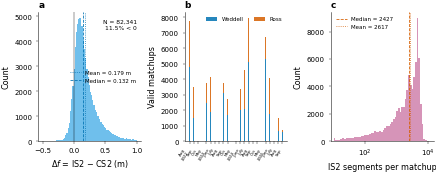

Figure 1 saved (3 panels, Weddell+Ross only, N = 82,341)


In [6]:
# -- Filter to winter Weddell + Ross ONLY (Alex #12) --------------
df_wr = df[df.is_winter & df.sector.isin(['Weddell', 'Ross'])].copy()
print(f'Winter Weddell+Ross matchups: {len(df_wr):,}')

fig, axes = plt.subplots(1, 3, figsize=(7.08, 3.2))
fig.subplots_adjust(wspace=0.42, bottom=0.32)

_mn_names = {5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct'}
_mn_full  = {5:'May', 6:'June', 7:'July', 8:'Aug', 9:'Sep', 10:'Oct'}

winter_yms = sorted(df_wr.year_month.unique())
year_breaks = []
for i in range(len(winter_yms) - 1):
    m1 = int(str(winter_yms[i])[4:6])
    m2 = int(str(winter_yms[i+1])[4:6])
    if m1 == 10 and m2 == 5:
        year_breaks.append(i)

x = np.zeros(len(winter_yms))
gap = 5.0
spacing = 5.0
offset = 1.0
for i in range(len(winter_yms)):
    x[i] = i * spacing + offset
    if i in year_breaks:
        offset += gap

first_of_season = {0}
for brk in year_breaks:
    first_of_season.add(brk + 1)

# (a) Freeboard difference distribution
ax = axes[0]
fb = df_wr.delta_f
ax.hist(fb, bins=80, range=(-0.5, 1.0), color=C_SKY, alpha=0.85,
        edgecolor='none', linewidth=0)
ax.axvline(fb.mean(), color=C_WEDDELL, ls=':', lw=0.8,
           label=f'Mean = {fb.mean():.3f} m')
ax.axvline(fb.median(), color=C_WEDDELL, ls='--', lw=0.8,
           label=f'Median = {fb.median():.3f} m')
ax.axvline(0, color='black', ls='-', lw=0.4)
pct_neg = 100 * (fb < 0).sum() / len(fb)
ax.text(0.96, 0.94, f'N = {len(fb):,}\n{pct_neg:.1f}% < 0',
        transform=ax.transAxes, va='top', ha='right', fontsize=7,
        bbox=dict(fc='white', alpha=0.85, ec='none', pad=1.5))
nature_ax(ax, xlabel=r'$\Delta f$ = IS2 $-$ CS2 (m)',
          ylabel='Count', title='a')
ax.legend(frameon=False, fontsize=7, loc='center right')
ax.tick_params(labelsize=7)

# (b) Monthly matchup count -- ALEX COMMENT 1: month text larger
ax = axes[1]
w_c = np.array([((df_wr.year_month==ym) & (df_wr.sector=='Weddell')
                 & df_wr.hs_valid).sum() for ym in winter_yms])
r_c = np.array([((df_wr.year_month==ym) & (df_wr.sector=='Ross')
                 & df_wr.hs_valid).sum() for ym in winter_yms])
ax.bar(x, w_c, color=C_WEDDELL, alpha=0.85, width=0.82, label='Weddell')
ax.bar(x, r_c, bottom=w_c, color=C_ROSS, alpha=0.85, width=0.82,
       label='Ross')

ax.set_xticks(x)
labels_b = []
for idx_ym, ym in enumerate(winter_yms):
    mn = int(str(ym)[4:6])
    yr = str(ym)[:4]
    if idx_ym in first_of_season:
        labels_b.append(f'{_mn_full[mn]}\n{yr}')
    else:
        labels_b.append(_mn_full[mn])
# ALEX COMMENT 1: fontsize 4 -> 7
ax.set_xticklabels(labels_b, fontsize=7, rotation=60, ha='right')
nature_ax(ax, ylabel='Valid matchups', title='b')
ax.legend(frameon=False, fontsize=7, ncol=2, loc='upper right')
ax.tick_params(axis='y', labelsize=7)

# (c) IS2 segments per matchup
ax = axes[2]
log_bins = np.logspace(np.log10(10), np.log10(15000), 60)
ax.hist(df_wr.n_is2, bins=log_bins, color=C_ACCENT, alpha=0.8,
        edgecolor='none')
ax.axvline(df_wr.n_is2.median(), color=C_ROSS, ls='--', lw=0.8,
           label=f'Median = {df_wr.n_is2.median():.0f}')
ax.axvline(df_wr.n_is2.mean(), color=C_ROSS, ls=':', lw=0.8,
           label=f'Mean = {df_wr.n_is2.mean():.0f}')
ax.set_xscale('log')
ax.set_xlim(8, 15000)
nature_ax(ax, xlabel='IS2 segments per matchup',
          ylabel='Count', title='c')
ax.legend(frameon=False, fontsize=7)
ax.tick_params(labelsize=7)

plt.savefig(f'{FIG_DIR}/Fig1_collocation_characteristics.pdf')
plt.savefig(f'{FIG_DIR}/Fig1_collocation_characteristics.png', dpi=600)
plt.show()
print(f'Figure 1 saved (larger month labels per Alex comment 1)')


## Figure 2: Regional Snow-Thickness Distributions (3 panels) → §4.2, §4.3

Weddell: n = 47,735, negatives = 5,288 (11.1%)
Ross:    n = 34,606, negatives = 4,146 (12.0%)
Expected: Weddell n ~ 47,735 (11.1% neg), Ross n ~ 34,606 (12.0% neg)


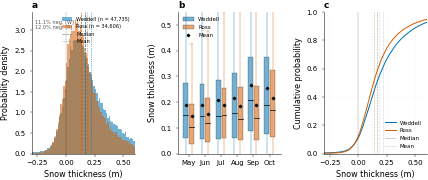

Figure 2 saved (all values including negatives, median + mean annotated).


In [7]:
# ── Define df_w for this cell (winter, Weddell+Ross only) ────────
df_w = df[df.is_winter & df.sector.isin(['Weddell', 'Ross'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(7.08, 2.6))
fig.subplots_adjust(wspace=0.42)
 
# ── CRITICAL: Use df_w (unfiltered), NOT dw (valid only) ─────────────────────
# Filter by sector only — do NOT filter by hs_valid
w_hs_all = df_w[df_w.sector == 'Weddell'].snow_thickness
r_hs_all = df_w[df_w.sector == 'Ross'].snow_thickness
 
# Compute negative fractions for annotation
w_n_neg = (w_hs_all < 0).sum()
r_n_neg = (r_hs_all < 0).sum()
w_pct_neg = 100 * w_n_neg / len(w_hs_all) if len(w_hs_all) > 0 else 0
r_pct_neg = 100 * r_n_neg / len(r_hs_all) if len(r_hs_all) > 0 else 0
 
# Sanity check — print to confirm negatives are present
print(f'Weddell: n = {len(w_hs_all):,}, negatives = {w_n_neg:,} ({w_pct_neg:.1f}%)')
print(f'Ross:    n = {len(r_hs_all):,}, negatives = {r_n_neg:,} ({r_pct_neg:.1f}%)')
print(f'Expected: Weddell n ~ 47,735 (11.1% neg), Ross n ~ 34,606 (12.0% neg)')
 
# ── (a) Overlaid probability density — ALL values ────────────────────────────
ax = axes[0]
bins = np.arange(-0.3, 0.65, 0.012)
ax.hist(w_hs_all, bins=bins, alpha=0.55, color=C_WEDDELL, density=True,
        label=f'Weddell (n = {len(w_hs_all):,})', edgecolor='none')
ax.hist(r_hs_all, bins=bins, alpha=0.55, color=C_ROSS, density=True,
        label=f'Ross (n = {len(r_hs_all):,})', edgecolor='none')
 
# Median (dashed) and Mean (dotted) lines
ax.axvline(w_hs_all.median(), color=C_WEDDELL, ls='--', lw=0.7)
ax.axvline(w_hs_all.mean(),   color=C_WEDDELL, ls=':',  lw=0.7)
ax.axvline(r_hs_all.median(), color=C_ROSS,    ls='--', lw=0.7)
ax.axvline(r_hs_all.mean(),   color=C_ROSS,    ls=':',  lw=0.7)
 
# Zero line to mark the positive/negative boundary
ax.axvline(0, color='black', ls='-', lw=0.4, alpha=0.4)
 
# Legend entries for line styles
ax.plot([], [], color='grey', ls='--', lw=0.7, label='Median')
ax.plot([], [], color='grey', ls=':',  lw=0.7, label='Mean')
 
nature_ax(ax, xlabel='Snow thickness (m)', ylabel='Probability density',
          title='a')
ax.set_xlim(-0.3, 0.6)
 
# Annotate negative fraction — upper left where the negative tail is small
ax.text(0.03, 0.95,
        f'{w_pct_neg:.1f}% neg. (W)\n{r_pct_neg:.1f}% neg. (R)',
        transform=ax.transAxes, fontsize=5, va='top', ha='left',
        color='#555555',
        bbox=dict(fc='white', alpha=0.8, ec='none', pad=1.0))
 
# Legend: upper right — the peak is near 0-0.1 m so upper right is clear
ax.legend(frameon=False, fontsize=5, ncol=1, loc='upper right')
 
 
# ── (b) Monthly box plots by sector — ALL values ────────────────────────────
ax = axes[1]
positions_w = np.array([5, 6, 7, 8, 9, 10]) - 0.18
positions_r = np.array([5, 6, 7, 8, 9, 10]) + 0.18
 
# Use df_w (not dw) so box plots include negative values
w_by_m = [df_w[(df_w.sector == 'Weddell') & (df_w.month == m)].snow_thickness.dropna().values
           for m in range(5, 11)]
r_by_m = [df_w[(df_w.sector == 'Ross') & (df_w.month == m)].snow_thickness.dropna().values
           for m in range(5, 11)]
 
bp_kw = dict(widths=0.3, patch_artist=True, showfliers=False,
             medianprops=dict(color='black', lw=0.7),
             whiskerprops=dict(lw=0.4),
             capprops=dict(lw=0.4),
             boxprops=dict(lw=0.4),
             showmeans=True,
             meanprops=dict(marker='D', markerfacecolor='black',
                            markeredgecolor='black', markersize=2))
 
bp1 = ax.boxplot(w_by_m, positions=positions_w, **bp_kw)
bp2 = ax.boxplot(r_by_m, positions=positions_r, **bp_kw)
for b in bp1['boxes']:
    b.set_facecolor(C_WEDDELL)
    b.set_alpha(0.55)
for b in bp2['boxes']:
    b.set_facecolor(C_ROSS)
    b.set_alpha(0.55)
for el in ['whiskers', 'caps']:
    for item in bp1[el]:
        item.set_color(C_WEDDELL)
    for item in bp2[el]:
        item.set_color(C_ROSS)
 
ax.set_xticks(range(5, 11))
ax.set_xticklabels(['May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct'])
nature_ax(ax, ylabel='Snow thickness (m)', title='b')
ax.set_ylim(0, 0.55)
 
# Legend: upper left — box plots grow toward upper right
ax.legend([bp1['boxes'][0], bp2['boxes'][0], bp1['means'][0]],
          ['Weddell', 'Ross', 'Mean'],
          frameon=False, fontsize=5.5, loc='upper left')
 
 
# ── (c) CDF comparison — ALL values ─────────────────────────────────────────
ax = axes[2]
for sector, color in [('Weddell', C_WEDDELL), ('Ross', C_ROSS)]:
    # Use df_w (not dw) for CDF to include negatives
    vals = df_w[df_w.sector == sector].snow_thickness.sort_values().values
    cdf  = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, color=color, lw=1.0, label=sector)
    med = np.median(vals)
    mn  = np.mean(vals)
    ax.axvline(med, color=color, ls='--', lw=0.5, alpha=0.6)
    ax.axvline(mn,  color=color, ls=':',  lw=0.5, alpha=0.6)
 
# Zero line
ax.axvline(0, color='black', ls='-', lw=0.4, alpha=0.4)
 
# Dummy entries for median/mean line styles
ax.plot([], [], color='grey', ls='--', lw=0.5, label='Median')
ax.plot([], [], color='grey', ls=':',  lw=0.5, label='Mean')
 
nature_ax(ax, xlabel='Snow thickness (m)',
          ylabel='Cumulative probability', title='c')
ax.set_xlim(-0.3, 0.6)
ax.set_ylim(0, 1)
 
# Legend: lower right — CDF curves rise through upper left
ax.legend(frameon=False, fontsize=5.5, ncol=1, loc='lower right')
ax.grid(True, alpha=0.15, lw=0.3)
 
 
plt.savefig(f'{FIG_DIR}/Fig2_regional_distributions.pdf')
plt.savefig(f'{FIG_DIR}/Fig2_regional_distributions.png', dpi=600)
plt.show()
print('Figure 2 saved (all values including negatives, median + mean annotated).')

## Figure 3: Temporal Evolution (2 panels) → §4.3

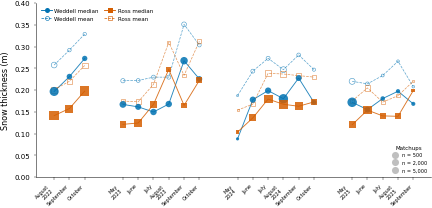

Figure 4 saved (median + mean, full month labels, size-scaled markers).


In [8]:
MIN_N = 50
df_w = df[df.is_winter & df.sector.isin(['Weddell', 'Ross'])].copy()
winter_yms = sorted(df_w.year_month.unique())
_mn_full = {5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October'}

# Build monthly statistics
rows = []
for ym in winter_yms:
    row = {'ym': ym}
    for sec in ['Weddell', 'Ross']:
        m = (df_w.year_month == ym) & (df_w.sector == sec) & df_w.hs_valid
        row[f'{sec}_n']    = m.sum()
        row[f'{sec}_med']  = df_w[m].snow_thickness.median() if m.sum() > 0 else np.nan
        row[f'{sec}_mean'] = df_w[m].snow_thickness.mean()   if m.sum() > 0 else np.nan
    rows.append(row)
ms = pd.DataFrame(rows)

year_breaks = []
for i in range(len(winter_yms) - 1):
    m1 = int(str(winter_yms[i])[4:6])
    m2 = int(str(winter_yms[i+1])[4:6])
    if m1 == 10 and m2 == 5:
        year_breaks.append(i)

x_pos = np.zeros(len(winter_yms))
gap = 1.5
offset = 0
for i in range(len(winter_yms)):
    x_pos[i] = i + offset
    if i in year_breaks:
        offset += gap

def scale_size(n_arr, s_min=15, s_max=110):
    n_arr = np.array(n_arr, dtype=float)
    n_min, n_max = np.nanmin(n_arr), np.nanmax(n_arr)
    if n_max == n_min:
        return np.full_like(n_arr, (s_min + s_max) / 2)
    return s_min + (s_max - s_min) * (n_arr - n_min) / (n_max - n_min)

all_n = np.concatenate([ms['Weddell_n'].values, ms['Ross_n'].values])

# PLOT (increased figure height for more room)
fig, ax = plt.subplots(figsize=(7.08, 3.6))
fig.subplots_adjust(bottom=0.22)

for sec, color, mkr in [('Weddell', C_WEDDELL, 'o'), ('Ross', C_ROSS, 's')]:
    med    = ms[f'{sec}_med'].values
    mn_val = ms[f'{sec}_mean'].values
    n_vals = ms[f'{sec}_n'].values
    sizes  = scale_size(n_vals)

    seg_start = 0
    first_seg = True
    for brk in year_breaks + [len(winter_yms) - 1]:
        seg = slice(seg_start, brk + 1)
        v_med  = np.isfinite(med[seg])
        v_mean = np.isfinite(mn_val[seg])

        if v_med.any():
            ax.plot(x_pos[seg][v_med], med[seg][v_med], '-', color=color,
                    lw=1.0, alpha=0.85)

        if v_mean.any():
            ax.plot(x_pos[seg][v_mean], mn_val[seg][v_mean], '--', color=color,
                    lw=0.8, alpha=0.65)

        seg_start = brk + 1

    valid = np.isfinite(med)
    ax.scatter(x_pos[valid], med[valid], s=sizes[valid], marker=mkr,
               color=color, alpha=0.85, edgecolors='none', zorder=5,
               label=f'{sec} median')

    valid_mn = np.isfinite(mn_val)
    ax.scatter(x_pos[valid_mn], mn_val[valid_mn], s=sizes[valid_mn] * 0.4,
               marker=mkr, facecolors='none', edgecolors=color, lw=0.6,
               zorder=4, alpha=0.7, label=f'{sec} mean')

# X-axis: full month names -- ALEX COMMENT 3: month text larger
ax.set_xticks(x_pos)
labels = []
for ym in winter_yms:
    mn = int(str(ym)[4:6])
    yr = str(ym)[2:4]
    if mn == 5:
        labels.append(f'{_mn_full[mn]}\n20{yr}')
    elif mn == 8:
        labels.append(f'{_mn_full[mn]}\n20{yr}')
    else:
        labels.append(_mn_full[mn])
# ALEX COMMENT 3: fontsize 5 -> 7
ax.set_xticklabels(labels, fontsize=7, rotation=45, ha='right')

nature_ax(ax, ylabel='Snow thickness (m)')
ax.set_ylim(0, 0.40)
ax.tick_params(axis='y', labelsize=7)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color=C_WEDDELL, lw=1.0, markersize=6,
           markeredgewidth=0, label='Weddell median'),
    Line2D([0], [0], marker='o', color=C_WEDDELL, lw=0.8, ls='--',
           markersize=5, markerfacecolor='none', markeredgecolor=C_WEDDELL,
           markeredgewidth=0.8, label='Weddell mean'),
    Line2D([0], [0], marker='s', color=C_ROSS, lw=1.0, markersize=6,
           markeredgewidth=0, label='Ross median'),
    Line2D([0], [0], marker='s', color=C_ROSS, lw=0.8, ls='--',
           markersize=5, markerfacecolor='none', markeredgecolor=C_ROSS,
           markeredgewidth=0.8, label='Ross mean'),
]

# ALEX COMMENT 3: legend fontsize 5.5 -> 7
leg1 = ax.legend(handles=legend_elements, frameon=False, fontsize=7,
                 ncol=2, loc='upper left',
                 columnspacing=1.0, handletextpad=0.4)
ax.add_artist(leg1)

# Size scale legend -- ALEX COMMENT 3: n= text larger (fontsize 5 -> 7)
size_legend = []
for n_ex in [500, 2000, 5000]:
    s_ex = scale_size(np.array([n_ex]), s_min=15, s_max=110)[0]
    size_legend.append(
        Line2D([0], [0], marker='o', color='grey', lw=0, markersize=np.sqrt(s_ex),
               markeredgewidth=0, alpha=0.5, label=f'n = {n_ex:,}')
    )
ax.legend(handles=size_legend, frameon=False, fontsize=7, loc='lower right',
          title='Matchups', title_fontsize=7, handletextpad=0.3)

plt.savefig(f'{FIG_DIR}/Fig3_temporal_evolution.pdf')
plt.savefig(f'{FIG_DIR}/Fig3_temporal_evolution.png', dpi=600)
plt.show()
print('Figure 3 saved (month and n= labels 5pt -> 7pt per Alex comment 3).')


## Figure 4: Circumpolar Polar Map with Sector Boundaries → §4.2

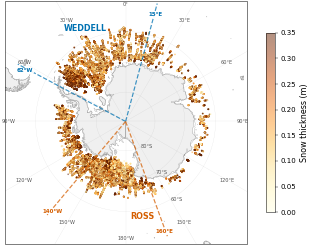

Figure 4 saved.


In [9]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    has_cartopy = True
except ImportError:
    has_cartopy = False
    print('Cartopy not available - skip Figure 4')

if has_cartopy:
    proj = ccrs.SouthPolarStereo()
    fig = plt.figure(figsize=(5.5, 5.5))
    ax = fig.add_subplot(1, 1, 1, projection=proj)
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0',
                   edgecolor='#888888', linewidth=0.3)
    ax.coastlines(resolution='50m', linewidth=0.25, color='#888888')

    # ── Gridlines with longitude labels ──────────────────────────
    gl = ax.gridlines(crs=ccrs.PlateCarree(),
                      draw_labels=False,
                      linewidth=0.2, alpha=0.3, color='grey',
                      xlocs=np.arange(-180, 180, 30),
                      ylocs=[-60, -70, -80])

    # Manual longitude labels at the map edge (~52°S)
    label_lat = -51.5
    for lon in np.arange(-180, 180, 30):
        if lon == 0:
            label = '0°'
        elif lon > 0:
            label = f'{lon}°E'
        else:
            label = f'{abs(lon)}°W'
        ax.text(lon, label_lat, label, fontsize=5, ha='center',
                va='center', transform=ccrs.PlateCarree(),
                color='#555555')

    # Manual latitude labels along 150°E meridian
    for lat in [-60, -70, -80]:
        ax.text(150, lat, f'{abs(lat)}°S', fontsize=5,
                ha='left', va='center',
                transform=ccrs.PlateCarree(), color='#555555')

    # ── Data points ──────────────────────────────────────────────
    sc = ax.scatter(dw.lon, dw.lat, c=dw.snow_thickness,
                    s=0.5, cmap='YlOrBr', vmin=0, vmax=0.35,
                    alpha=0.5, transform=ccrs.PlateCarree(),
                    rasterized=True)

    # ── Sector boundary lines with longitude annotations ─────────
    bla = np.linspace(-90, -50, 100)

    # Weddell boundaries: -62°W and 15°E
    for lon_b, label in [(-62, '62°W'), (15, '15°E')]:
        ax.plot([lon_b]*len(bla), bla, color=C_WEDDELL, lw=1.2,
                ls='--', alpha=0.75, transform=ccrs.PlateCarree())
        ax.text(lon_b, -52.5, label, fontsize=5.5, fontweight='bold',
                color=C_WEDDELL, ha='center', va='top',
                transform=ccrs.PlateCarree(),
                bbox=dict(fc='white', alpha=0.9, ec='none', pad=0.5))

    # Ross boundaries: 160°E and 140°W
    for lon_b, label in [(160, '160°E'), (-140, '140°W')]:
        ax.plot([lon_b]*len(bla), bla, color=C_ROSS, lw=1.2,
                ls='--', alpha=0.75, transform=ccrs.PlateCarree())
        ax.text(lon_b, -52.5, label, fontsize=5.5, fontweight='bold',
                color=C_ROSS, ha='center', va='top',
                transform=ccrs.PlateCarree(),
                bbox=dict(fc='white', alpha=0.9, ec='none', pad=0.5))

    # ── Sector name labels ───────────────────────────────────────
    ax.text(-24, -57, 'WEDDELL', fontsize=8, fontweight='bold',
            color=C_WEDDELL, ha='center', transform=ccrs.PlateCarree(),
            bbox=dict(fc='white', alpha=0.85, ec='none', pad=1))
    ax.text(170, -57, 'ROSS', fontsize=8, fontweight='bold',
            color=C_ROSS, ha='center', transform=ccrs.PlateCarree(),
            bbox=dict(fc='white', alpha=0.85, ec='none', pad=1))

    # ── Colorbar ─────────────────────────────────────────────────
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.06, aspect=20)
    cbar.set_label('Snow thickness (m)', fontsize=8)
    cbar.set_ticks([0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35])
    cbar.ax.tick_params(labelsize=7)

    plt.savefig(f'{FIG_DIR}/Fig4_polar_map.pdf')
    plt.savefig(f'{FIG_DIR}/Fig4_polar_map.png', dpi=600)
    plt.show()
    print('Figure 4 saved.')

## Figure 5: Uncertainty Decomposition (2 panels) → §4.4

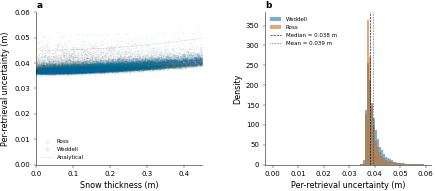

Figure 5 saved (median + mean annotated).


In [10]:
has_unc = 'snow_thickness_unc' in dw.columns

if has_unc:
    fig, axes = plt.subplots(1, 2, figsize=(7.08, 2.8))
    fig.subplots_adjust(wspace=0.38)

    # ── (a) Snow thickness vs uncertainty ─────────────────────────
    ax = axes[0]
    for sec, col in [('Ross', C_ROSS), ('Weddell', C_WEDDELL)]:
        m = dw.sector == sec
        ax.scatter(dw[m].snow_thickness, dw[m].snow_thickness_unc,
                   s=0.15, alpha=0.08, c=col, rasterized=True, label=sec)
    # Theoretical line
    hs_range = np.linspace(0.01, 0.5, 100)
    sigma_eta = 0.060
    eta_s = 1.263
    sigma_cs2 = 0.03
    sigma_is2 = dw.snow_thickness_unc.median() * eta_s
    sigma_th = np.sqrt(sigma_is2**2/eta_s**2 + sigma_cs2**2/eta_s**2
                       + (hs_range*eta_s*sigma_eta/eta_s**2)**2)
    ax.plot(hs_range, sigma_th, color='black', ls=':', lw=0.5,
            alpha=0.4, label='Analytical')
    nature_ax(ax, xlabel='Snow thickness (m)',
              ylabel='Per-retrieval uncertainty (m)', title='a')
    ax.set_xlim(0, 0.45); ax.set_ylim(0, 0.06)
    ax.legend(frameon=False, fontsize=5.5, markerscale=8)

    # ── (b) Uncertainty PDF by sector ─────────────────────────────
    ax = axes[1]
    bins_u = np.arange(0, 0.06, 0.0008)
    for sec, col in [('Weddell', C_WEDDELL), ('Ross', C_ROSS)]:
        m = dw.sector == sec
        ax.hist(dw[m].snow_thickness_unc, bins=bins_u, alpha=0.55,
                color=col, density=True, edgecolor='none', label=sec)
    med_unc = dw.snow_thickness_unc.median()
    mean_unc = dw.snow_thickness_unc.mean()
    ax.axvline(med_unc, color='black', ls='--', lw=0.6,
               label=f'Median = {med_unc:.3f} m')
    ax.axvline(mean_unc, color='black', ls=':', lw=0.6,
               label=f'Mean = {mean_unc:.3f} m')
    nature_ax(ax, xlabel='Per-retrieval uncertainty (m)',
              ylabel='Density', title='b')
    ax.legend(frameon=False, fontsize=5.5)

    plt.savefig(f'{FIG_DIR}/Fig5_uncertainty.pdf')
    plt.savefig(f'{FIG_DIR}/Fig5_uncertainty.png', dpi=600)
    plt.show()
    print('Figure 5 saved (median + mean annotated).')
else:
    print('No uncertainty column - skip Figure 5')


## Figure 6: AMSR2 Benchmarking (3 panels) → §4.5

Weddell: r=0.250, r²=0.0624, p(nominal)=0.00e+00, n_eff=17743, p(n_eff)=1.95e-250
Ross:    r=0.027, r²=0.0008, p(nominal)=3.45e-06, n_eff=12512, p(n_eff)=2.10e-03


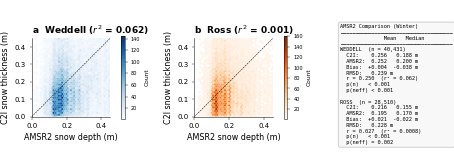

Figure 6 saved (mean first, r², n_eff-corrected p).


In [11]:
if has_amsr2:
    vc = dw.hs_valid & (dw.AMSR2_snow_depth > 0) & (dw.AMSR2_snow_depth <= 1.0)
    dc = dw[vc].copy()
    wc = dc[dc.sector == 'Weddell']
    rc = dc[dc.sector == 'Ross']

    # n_eff correction: Method 1 only (Alex decision)
    r1 = 0.39
    neff_factor = (1 - r1) / (1 + r1)

    # ALEX COMMENT 4: Remove panel (c) - move stats to main text
    # Two-panel figure allows panels (a) and (b) to be ENLARGED
    fig, axes = plt.subplots(1, 2, figsize=(7.08, 3.3))
    fig.subplots_adjust(wspace=0.38, left=0.10, right=0.95,
                        bottom=0.18, top=0.90)

    # (a) Weddell hexbin
    ax = axes[0]
    hb = ax.hexbin(wc.AMSR2_snow_depth, wc.snow_thickness,
                   gridsize=40, cmap='Blues', mincnt=1,
                   extent=[0, 0.5, 0, 0.5], linewidths=0.1)
    cb_w = fig.colorbar(hb, ax=ax, shrink=0.85, pad=0.03,
                        aspect=25, fraction=0.046)
    cb_w.set_label('Count', fontsize=8)
    cb_w.ax.tick_params(labelsize=7)
    ax.plot([0, 0.5], [0, 0.5], color='black', ls='--', lw=0.6)
    r_w, p_w = pearsonr(wc.AMSR2_snow_depth, wc.snow_thickness)
    nature_ax(ax, xlabel='AMSR2 snow depth (m)',
              ylabel='C2I snow thickness (m)',
              title=f'a  Weddell ($r^2$ = {r_w**2:.3f}, n = {len(wc):,})')
    ax.set_xlim(0, 0.45); ax.set_ylim(0, 0.45)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)

    # (b) Ross hexbin
    ax = axes[1]
    hb = ax.hexbin(rc.AMSR2_snow_depth, rc.snow_thickness,
                   gridsize=40, cmap='Oranges', mincnt=1,
                   extent=[0, 0.5, 0, 0.5], linewidths=0.1)
    cb_r = fig.colorbar(hb, ax=ax, shrink=0.85, pad=0.03,
                        aspect=25, fraction=0.046)
    cb_r.set_label('Count', fontsize=8)
    cb_r.ax.tick_params(labelsize=7)
    ax.plot([0, 0.5], [0, 0.5], color='black', ls='--', lw=0.6)
    r_r, p_r = pearsonr(rc.AMSR2_snow_depth, rc.snow_thickness)
    nature_ax(ax, xlabel='AMSR2 snow depth (m)',
              ylabel='C2I snow thickness (m)',
              title=f'b  Ross ($r^2$ = {r_r**2:.3f}, n = {len(rc):,})')
    ax.set_xlim(0, 0.45); ax.set_ylim(0, 0.45)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)

    # Compute n_eff-corrected p-values (still printed for manuscript use)
    from scipy.stats import t as t_dist
    neff_w = len(wc) * neff_factor
    neff_r = len(rc) * neff_factor
    t_w = r_w * np.sqrt(neff_w - 2) / np.sqrt(1 - r_w**2)
    t_r = r_r * np.sqrt(neff_r - 2) / np.sqrt(1 - r_r**2)
    p_w_neff = 2 * t_dist.sf(abs(t_w), df=neff_w - 2)
    p_r_neff = 2 * t_dist.sf(abs(t_r), df=neff_r - 2)

    d_w = wc.snow_thickness.values - wc.AMSR2_snow_depth.values
    d_r = rc.snow_thickness.values - rc.AMSR2_snow_depth.values

    print('=' * 75)
    print('AMSR2 Comparison Statistics (move these numbers into main text)')
    print('=' * 75)
    print(f'WEDDELL (n = {len(wc):,})')
    print(f'  C2I:    mean={wc.snow_thickness.mean():.3f}  median={wc.snow_thickness.median():.3f} m')
    print(f'  AMSR2:  mean={wc.AMSR2_snow_depth.mean():.3f}  median={wc.AMSR2_snow_depth.median():.3f} m')
    print(f'  Bias:   mean={np.mean(d_w):+.3f}  median={np.median(d_w):+.3f} m')
    print(f'  RMSD:   {np.sqrt(np.mean(d_w**2)):.3f} m')
    print(f'  r = {r_w:.3f}  r2 = {r_w**2:.3f}')
    print(f'  p(nominal) = {p_w:.2e}   p(n_eff) = {p_w_neff:.2e}')
    print(f'  n_eff = {neff_w:.0f}')
    print()
    print(f'ROSS (n = {len(rc):,})')
    print(f'  C2I:    mean={rc.snow_thickness.mean():.3f}  median={rc.snow_thickness.median():.3f} m')
    print(f'  AMSR2:  mean={rc.AMSR2_snow_depth.mean():.3f}  median={rc.AMSR2_snow_depth.median():.3f} m')
    print(f'  Bias:   mean={np.mean(d_r):+.3f}  median={np.median(d_r):+.3f} m')
    print(f'  RMSD:   {np.sqrt(np.mean(d_r**2)):.3f} m')
    print(f'  r = {r_r:.3f}  r2 = {r_r**2:.4f}')
    print(f'  p(nominal) = {p_r:.2e}   p(n_eff) = {p_r_neff:.2e}')
    print(f'  n_eff = {neff_r:.0f}')

    plt.savefig(f'{FIG_DIR}/Fig6_amsr2_comparison.pdf')
    plt.savefig(f'{FIG_DIR}/Fig6_amsr2_comparison.png', dpi=600)
    plt.show()
    print('\nFigure 6 saved (2-panel layout; stats panel removed per Alex comment 4).')
else:
    print('No AMSR2 data - skip Figure 6')


## Table 5: AMSR2 Comparison Statistics (LaTeX) → §4.5

Includes r², nominal and n_eff-corrected p-values (Method 1 only, r₁ = 0.39).

In [12]:
if has_amsr2:
    vc = dw.hs_valid & (dw.AMSR2_snow_depth > 0) & (dw.AMSR2_snow_depth <= 1.0)
    dc = dw[vc]

    # ─── n_eff correction: Method 1 only ─────────────────────────
    r1 = 0.39
    neff_factor = (1 - r1) / (1 + r1)  # = 0.4388
    from scipy.stats import t as t_dist

    print(r'\begin{table}[htbp]')
    print(r'\centering')
    print(r'\caption{AMSR2 benchmarking statistics for austral winter')
    print(r'(May--October), stratified by sector.')
    print(r'Correlations and $p$-values are reported both at the')
    print(r'nominal sample size $n$ and at the effective sample')
    print(r'size $n_{\mathrm{eff}}$')
    print(r'(Equation~\ref{eq:neff1}; Table~\ref{tab:autocorrelation}).}')
    print(r'\label{tab:amsr2}')
    print(r'\small')
    print(r'\begin{tabular}{l c c}')
    print(r'\hline')
    print(r' & \textbf{Weddell Sea} & \textbf{Ross Sea} \\')
    print(r'\hline')

    for sec in ['Weddell', 'Ross']:
        sub = dc[dc.sector == sec]
        diff = sub.snow_thickness.values - sub.AMSR2_snow_depth.values
        r_val, p_val = pearsonr(sub.AMSR2_snow_depth, sub.snow_thickness)
        rmsd = np.sqrt(np.mean(diff**2))
        r2 = r_val**2

        # n_eff-corrected p-value
        neff = len(sub) * neff_factor
        t_stat = r_val * np.sqrt(neff - 2) / np.sqrt(1 - r_val**2)
        p_neff = 2 * t_dist.sf(abs(t_stat), df=neff - 2)

        if sec == 'Weddell':
            ws = (len(sub),
                  sub.snow_thickness.mean(), sub.snow_thickness.median(),
                  sub.AMSR2_snow_depth.mean(), sub.AMSR2_snow_depth.median(),
                  np.mean(diff), np.median(diff),
                  rmsd, r_val, r2, p_val, p_neff)
        else:
            rs = (len(sub),
                  sub.snow_thickness.mean(), sub.snow_thickness.median(),
                  sub.AMSR2_snow_depth.mean(), sub.AMSR2_snow_depth.median(),
                  np.mean(diff), np.median(diff),
                  rmsd, r_val, r2, p_val, p_neff)

    def fmt_p_latex(p):
        return r'$<$ 0.001' if p < 0.001 else f'{p:.3f}'

    tbl = [
        ('$n$',
         f'{ws[0]:,}', f'{rs[0]:,}'),
        (r'C2I mean (median) $h_s$ (m)',
         f'{ws[1]:.3f} ({ws[2]:.3f})',
         f'{rs[1]:.3f} ({rs[2]:.3f})'),
        ('AMSR2 mean (median) (m)',
         f'{ws[3]:.3f} ({ws[4]:.3f})',
         f'{rs[3]:.3f} ({rs[4]:.3f})'),
        (r'Mean (median) bias (m)',
         f'{ws[5]:+.3f} ({ws[6]:+.3f})',
         f'{rs[5]:+.3f} ({rs[6]:+.3f})'),
        ('RMSD (m)',
         f'{ws[7]:.3f}', f'{rs[7]:.3f}'),
        ('$r$',
         f'{ws[8]:.3f}', f'{rs[8]:.3f}'),
        ('$r^2$',
         f'{ws[9]:.3f}', f'{rs[9]:.4f}'),
        (r'$p$-value (nominal $n$)',
         fmt_p_latex(ws[10]), fmt_p_latex(rs[10])),
        (r'$p$-value ($n_{\mathrm{eff}}$)',
         fmt_p_latex(ws[11]), fmt_p_latex(rs[11])),
    ]

    for lab, w, r in tbl:
        print(f'{lab} & {w} & {r} \\\\')
    print(r'\hline')
    print(r'\end{tabular}')
    print(r'\end{table}')

    # ─── Also print plain-text summary for verification ──────────
    print('\n--- PLAIN-TEXT VERIFICATION ---')
    for name, vals in [('Weddell', ws), ('Ross', rs)]:
        print(f'\n{name} (n = {vals[0]:,}):')
        print(f'  C2I:   mean = {vals[1]:.3f}, median = {vals[2]:.3f}')
        print(f'  AMSR2: mean = {vals[3]:.3f}, median = {vals[4]:.3f}')
        print(f'  Bias:  mean = {vals[5]:+.3f}, median = {vals[6]:+.3f}')
        print(f'  RMSD = {vals[7]:.3f}')
        print(f'  r = {vals[8]:.3f}, r² = {vals[9]:.4f}')
        print(f'  p(nominal) = {vals[10]:.2e}')
        print(f'  p(n_eff)   = {vals[11]:.2e}')
        print(f'  n_eff = {vals[0] * neff_factor:.0f}')
else:
    print('No AMSR2 data — skip Table 5')


\begin{table}[htbp]
\centering
\caption{AMSR2 benchmarking statistics for austral winter
(May--October), stratified by sector.
Correlations and $p$-values are reported both at the
nominal sample size $n$ and at the effective sample
size $n_{\mathrm{eff}}$
(Equation~\ref{eq:neff1}; Table~\ref{tab:autocorrelation}).}
\label{tab:amsr2}
\small
\begin{tabular}{l c c}
\hline
 & \textbf{Weddell Sea} & \textbf{Ross Sea} \\
\hline
$n$ & 40,431 & 28,510 \\
C2I mean (median) $h_s$ (m) & 0.256 (0.188) & 0.216 (0.155) \\
AMSR2 mean (median) (m) & 0.252 (0.200) & 0.195 (0.170) \\
Mean (median) bias (m) & +0.004 (-0.038) & +0.021 (-0.022) \\
RMSD (m) & 0.239 & 0.228 \\
$r$ & 0.250 & 0.027 \\
$r^2$ & 0.062 & 0.0008 \\
$p$-value (nominal $n$) & $<$ 0.001 & $<$ 0.001 \\
$p$-value ($n_{\mathrm{eff}}$) & $<$ 0.001 & 0.002 \\
\hline
\end{tabular}
\end{table}

--- PLAIN-TEXT VERIFICATION ---

Weddell (n = 40,431):
  C2I:   mean = 0.256, median = 0.188
  AMSR2: mean = 0.252, median = 0.200
  Bias:  mean = +0

## Summary

In [13]:
figs = sorted(glob.glob(f'{FIG_DIR}/Fig*.png'))
print('=' * 62)
print('M2 MANUSCRIPT OUTPUTS — CORRECTED eta_s = 1.263')
print('=' * 62)
print(f'Dataset: {len(df):,} total matchups, {len(dw):,} winter valid')
print(f'Formula: h_s = delta_f / eta_s,  eta_s = 1.263 (rho_s = 330)')
print()
print('FIGURES:')
for f in figs:
    kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):45s} ({kb:6.0f} KB)')
print()
print('TABLES: Copy LaTeX from cell outputs above')
print('  Table 1 — Summary statistics by sector')
print('  Table 2 — Density sensitivity')
print('  Table 3 — AMSR2 comparison')
print()
print('PALETTE: Weddell=#0072B2 (blue), Ross=#D55E00 (vermillion)')
print('STYLE:   Nature (Helvetica 7pt, clean axes, 600 DPI)')


M2 MANUSCRIPT OUTPUTS — CORRECTED eta_s = 1.263
Dataset: 126,283 total matchups, 93,728 winter valid
Formula: h_s = delta_f / eta_s,  eta_s = 1.263 (rho_s = 330)

FIGURES:
  Fig1_collocation_characteristics.png          (   208 KB)
  Fig2_regional_distributions.png               (   278 KB)
  Fig3_temporal_evolution.png                   (   375 KB)
  Fig4_polar_map.png                            (  1470 KB)
  Fig5_uncertainty.png                          (   672 KB)
  Fig6_amsr2_comparison.png                     (   240 KB)

TABLES: Copy LaTeX from cell outputs above
  Table 1 — Summary statistics by sector
  Table 2 — Density sensitivity
  Table 3 — AMSR2 comparison

PALETTE: Weddell=#0072B2 (blue), Ross=#D55E00 (vermillion)
STYLE:   Nature (Helvetica 7pt, clean axes, 600 DPI)
